# MetaDrive Pretrained Agent XAI
This notebook demonstrates XAI techniques on your **pretrained DQN Agent**.
We will use:
1. **SHAP & LIME** (Feature): Applied directly to the Agent's Q-Network to explain value estimates.
2. **Grad-CAM** (Visual): Applied to a proxy model to provide visual context.


In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import cv2
from omegaconf import OmegaConf

# Add src to path
project_root = Path(os.getcwd()).parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.utils.config import load_config
from src.envs.metadrive_env import make_env
from src.agents.dqn_agent import DQNAgent

print(f'Project root: {project_root}')


Project root: /Users/tony/Documents/CSC790_001_XAI_Papers/Explaining-Autonomous-Vehicle-Decisions


## 1. Load Environment and Agent


In [2]:
# Load Config
config_path = project_root / 'configs/config.yaml'
cfg = load_config(str(config_path))

# Convert OmegaConf to dict
cfg_dict = OmegaConf.to_container(cfg, resolve=True)

# Configure Environment
if 'environment' not in cfg_dict:
    cfg_dict['environment'] = {}

cfg_dict['environment']['image_observation'] = False
cfg_dict['environment']['render'] = True
cfg_dict['environment']['traffic_density'] = 0.15 # Add some traffic
cfg_dict['environment']['map'] = 'C' # Curve map for interest

if 'vehicle_config' not in cfg_dict['environment']:
    cfg_dict['environment']['vehicle_config'] = {}
cfg_dict['environment']['vehicle_config']['image_source'] = 'main_camera'
if 'rgb_camera' in cfg_dict['environment']['vehicle_config']:
    del cfg_dict['environment']['vehicle_config']['rgb_camera']

# Create Env
env = make_env(cfg_dict)
print(f'Environment created. Obs space: {env.observation_space}')

# Initialize Agent
agent = DQNAgent(cfg, env.observation_space, env.action_space)

# Load Weights
model_path = project_root / 'outputs/dqn_highway_final.pt'
if model_path.exists():
    agent.load(str(model_path))
    print(f'Loaded agent from {model_path}')
else:
    print(f'Warning: Model not found at {model_path}. Using random weights.')


[INFO] Environment: MetaDriveEnv
[INFO] MetaDrive version: 0.4.3
[INFO] Sensors: [lidar: Lidar(), side_detector: SideDetector(), lane_line_detector: LaneLineDetector(), main_camera: MainCamera(1200, 900), dashboard: DashBoard()]
[INFO] Render Mode: onscreen
[INFO] Horizon (Max steps per agent): 1000


Environment created. Obs space: Box(-0.0, 1.0, (259,), float32)
Loaded agent from /Users/tony/Documents/CSC790_001_XAI_Papers/Explaining-Autonomous-Vehicle-Decisions/outputs/dqn_highway_final.pt


In [3]:
def get_feature_names(obs_shape):
    # MetaDrive 259-dim observation:
    # 0-18: Ego State (Speed, Steering, etc.)
    # 19-258: Lidar (240 beams)
    names = []
    # Ego State (approximate labels based on documentation)
    ego_labels = [
        'Steering', 'Heading Diff', 'Lane Dist', 'Lane Heading', 'Speed', 'Lat Speed',
        'Navi 1', 'Navi 2', 'Navi 3', 'Navi 4', 'Navi 5', 'Navi 6',
        'Past Action 1', 'Past Action 2', 'Yaw Rate', 'Lateral Acc', 'Long Acc', 'Gear', 'Brake'
    ]
    # Pad or truncate if exact match isn't perfect, but usually it's 19
    for i in range(19):
        if i < len(ego_labels):
            names.append(ego_labels[i])
        else:
            names.append(f'Ego_{i}')
            
    # Lidar
    num_lidar = obs_shape[0] - 19
    for i in range(num_lidar):
        names.append(f'Lidar_{i}')
        
    return names


In [4]:
def generate_video(frames, filename, fps=30):
    if not frames:
        print('No frames to generate video.')
        return
    
    height, width, layers = frames[0].shape
    # MP4V codec
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(filename, fourcc, fps, (width, height))
    
    for frame in frames:
        # OpenCV uses BGR, frames are RGB
        bgr_frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        out.write(bgr_frame)
        
    out.release()
    print(f'Video saved to {filename}')


## 2. Run Episode & Collect Data


In [5]:
obs, _ = env.reset()
frames = []
states = []
q_values_list = []

print('Running episode...')
for i in range(200):
    # Agent Action
    action = agent.act(obs, exploit=True)
    
    # Store State
    states.append(obs)
    
    # Store Q-values
    with torch.no_grad():
        state_t = torch.as_tensor(obs, dtype=torch.float32).to(agent.device).unsqueeze(0)
        q = agent.q_net(state_t).cpu().numpy()
        q_values_list.append(q[0])
    
    # Step
    obs, reward, term, trunc, info = env.step(action)
    
    # Capture Frame
    try:
        env.render()
        engine = env.unwrapped.engine
        if engine is not None:
            main_camera = engine.get_sensor('main_camera')
            if main_camera is not None:
                vehicle = env.unwrapped.agent
                main_camera.perceive(vehicle)
                main_camera.save_image(vehicle, 'temp_frame_nb2.png')
                if os.path.exists('temp_frame_nb2.png'):
                    img = plt.imread('temp_frame_nb2.png')
                    if img.dtype == np.float32:
                        img = (img * 255).astype(np.uint8)
                    if img.shape[-1] == 4:
                        img = img[..., :3]
                    frames.append(img)
                    os.remove('temp_frame_nb2.png')
    except Exception as e:
        pass
        
    if term or trunc:
        obs, _ = env.reset()

env.close()
states = np.array(states)
print(f'Collected {len(states)} states and {len(frames)} frames.')
    
# Save Simulation Video
if len(frames) > 0:
    os.makedirs('outputs', exist_ok=True)
    generate_video(frames, 'outputs/simulation_agent.mp4')


[INFO] Assets version: 0.4.3
[INFO] Known Pipes: CocoaGraphicsPipe
[INFO] Start Scenario Index: 42, Num Scenarios : 1


Running episode...
Collected 200 states and 200 frames.
Video saved to outputs/simulation_agent.mp4


## 3. Feature XAI: SHAP on Q-Network


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Computing SHAP (DeepExplainer)...


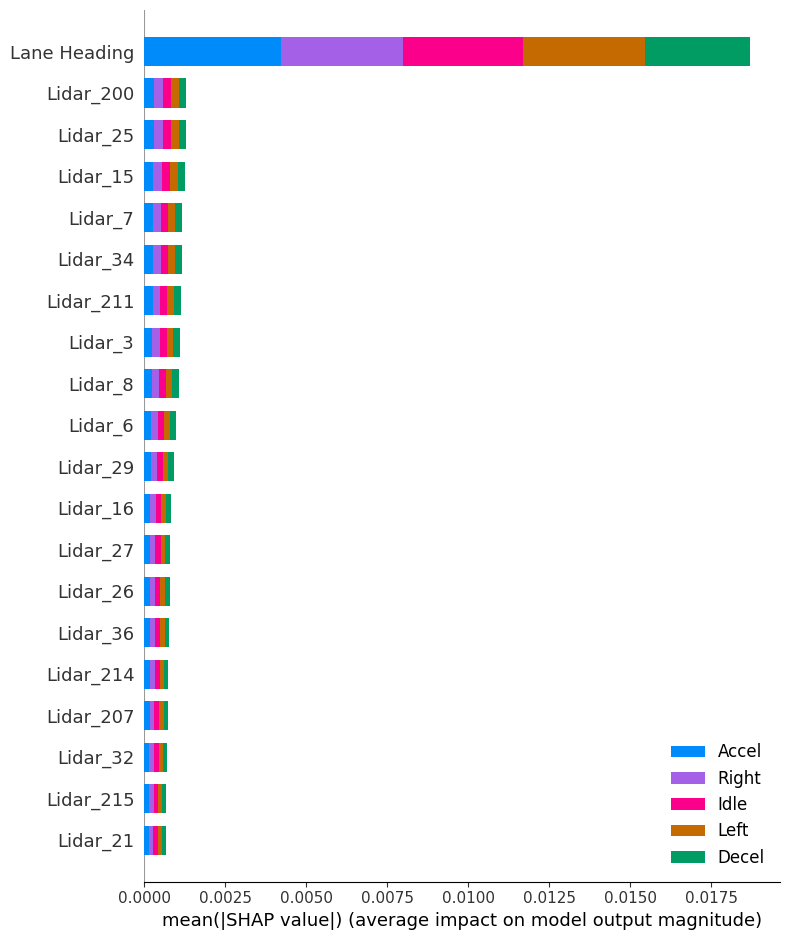

In [6]:
import shap

if len(states) > 0:
    # FIX: Use random sampling for background and test to ensure variance
    # Sample 100 random points for background
    bg_indices = np.random.choice(states.shape[0], 100, replace=False)
    background = torch.as_tensor(states[bg_indices], dtype=torch.float32).to(agent.device)
    
    # Sample 20 random points to explain
    test_indices = np.random.choice(states.shape[0], 20, replace=False)
    test_samples = torch.as_tensor(states[test_indices], dtype=torch.float32).to(agent.device)
    
    print('Computing SHAP (DeepExplainer)...')
    e = shap.DeepExplainer(agent.q_net, background)
    shap_values = e.shap_values(test_samples)
    
    # Feature Names
    feature_names = get_feature_names(states.shape[1:])
    
    # Class Names (DQN Actions)
    class_names = ['Idle', 'Accel', 'Decel', 'Left', 'Right']
    
    # Plot
    shap.summary_plot(shap_values, test_samples.cpu().numpy(), feature_names=feature_names, class_names=class_names)
else:
    print('No data for SHAP.')


## 4. Visual XAI: Grad-CAM (Context)


In [7]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision.models import resnet50
from tqdm import tqdm

if len(frames) > 0:
    model = resnet50(pretrained=True)
    target_layers = [model.layer4[-1]]
    cam = GradCAM(model=model, target_layers=target_layers)
    
    gradcam_frames = []
    print('Generating Grad-CAM video...')
    step_size = 1
    for i in tqdm(range(0, len(frames), step_size)):
        img = frames[i]
        # Preprocess
        img_resized = cv2.resize(img, (224, 224))
        rgb_img = np.float32(img_resized) / 255
        input_tensor = torch.from_numpy(rgb_img).permute(2, 0, 1).unsqueeze(0)
        
        # Generate CAM
        targets = [ClassifierOutputTarget(281)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0, :]
        
        # Overlay
        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        gradcam_frames.append(visualization)
    
    # Save Video
    generate_video(gradcam_frames, 'outputs/gradcam_agent.mp4')
else:
    print('No frames for Grad-CAM.')


The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.


Generating Grad-CAM video...


  0%|          | 0/200 [00:00<?, ?it/s]Fatal Python error: preconfig_init_utf8_mode: invalid PYTHONUTF8 environment variable value
Python runtime state: preinitializing

100%|██████████| 200/200 [02:40<00:00,  1.25it/s]

Video saved to outputs/gradcam_agent.mp4
